In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# Stage 27 — Conflicting gradients, interfaces, separability and PIKANs

Exact gradient examples and manufactured subdomain seams; opposing objectives derived from observed NIST regression groups.

This is an executed reference, not a learner assessment. Read the lesson and predict the results before running. All code is inspectable in `src/shape_lab/physics`. No model or dataset downloads occur.

In [2]:
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib','inline')
STAGE=27
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT=Path.cwd()
while not (ROOT/'pyproject.toml').exists() and ROOT.parent!=ROOT:ROOT=ROOT.parent
if not (ROOT/'pyproject.toml').exists():raise RuntimeError('Open this notebook within the extracted project.')
sys.path.insert(0,str(ROOT/'src'))
from shape_lab.physics import classical as c, constraints as con, gradients as grad, operators as op
hahn=pd.read_csv(ROOT/'data/physics/hahn1_excerpt.csv')
hahn_manifest=json.loads((ROOT/'data/physics/manifest.json').read_text())
OUT=ROOT/'physics/reports'/f'{STAGE:02d}'
OUT.mkdir(parents=True,exist_ok=True)
def save_report(result):
    result={'stage':STAGE,'role':'executed teaching experiment; not learner assessment',**result}
    result['source_review_date']='2026-09-20'
    (OUT/'results.json').write_text(json.dumps(result,indent=2,allow_nan=False)+'\n')
    print(json.dumps(result,indent=2))
def finish_figure(name):
    plt.tight_layout();plt.savefig(OUT/f'{name}.png',dpi=140,bbox_inches='tight');plt.show();plt.close()
print('Course:', ROOT.name, '| stage:', STAGE)


Course: course | stage: 27


## Inspect the requested gradient algorithms
Direction d means a step of −eta*d. The dot products, not the algorithm names, tell us first-order alignment.

In [3]:
G=np.array([[1.,0.],[-1.,1.]])
directions={'sum':G.sum(axis=0),'PCGrad':grad.pcgrad(G),'Norm-PCGrad':grad.pcgrad(G,normalise=True),'ConFIG':grad.config_direction(G)['direction']}
display(pd.DataFrame([{'method':k,'direction':v.tolist(),'g1_dot_d':float(G[0]@v),'g2_dot_d':float(G[1]@v)} for k,v in directions.items()]))
opposed=grad.config_direction([[1.,0.],[-1.,0.]])
assert not opposed['compatible'] and not opposed['strict_common_descent']

,method,direction,g1_dot_d,g2_dot_d
0,sum,"[0.0, 1.0]",0.000000,1.0
1,PCGrad,"[0.5, 1.5]",0.500000,1.0
2,Norm-PCGrad,"[0.7071067811865475, 1.7071067811865475]",0.707107,1.0
3,ConFIG,"[0.3535533905932738, 0.8535533905932736]",0.353553,0.5


## Real regression objectives can genuinely oppose each other
At a shared least-squares compromise, colder and warmer groups need not have any strictly common improvement direction.

In [4]:
ordered=hahn.sort_values('temperature_K');T=ordered.temperature_K.to_numpy();y=ordered.expansion_response.to_numpy()
a=(T-T.mean())/T.std();X=np.column_stack([np.ones(len(a)),a]);theta=np.linalg.lstsq(X,y,rcond=None)[0]
G_real=np.stack([2*X[sl].T@(X[sl]@theta-y[sl])/len(X[sl]) for sl in [slice(0,28),slice(28,56)]])
cos=grad.cosines(G_real)
print('Observed-objective gradients:',G_real,'cosine:',cos[0,1])
assert abs(cos[0,1]+1)<1e-10
real_diagnostic=grad.config_direction(G_real)
print('Equal-alignment compatible?',real_diagnostic['compatible'])

Observed-objective gradients: [[-0.47452302 -1.90497719]
 [ 0.47452302  1.90497719]] cosine: -1.0000000000000002
Equal-alignment compatible? False


## Interior residuals can hide a seam; separability does not erase output size
These are manufactured counterexamples, not trained XPINN/SPINN/PIKAN reproductions.

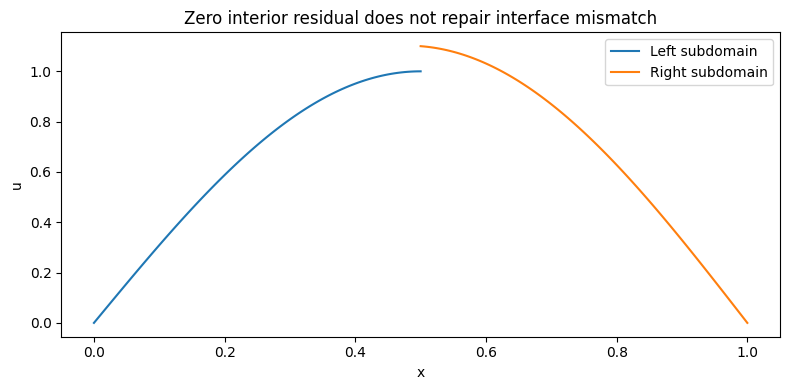

{
  "stage": 27,
  "role": "executed teaching experiment; not learner assessment",
  "data_kind": "analytic gradient and interface examples plus observed regression gradients",
  "two_objective_directions": {
    "sum": [
      0.0,
      1.0
    ],
    "PCGrad": [
      0.5,
      1.5
    ],
    "Norm-PCGrad": [
      0.7071067811865475,
      1.7071067811865475
    ],
    "ConFIG": [
      0.3535533905932738,
      0.8535533905932736
    ]
  },
  "observed_gradient_cosine": -1.0000000000000002,
  "observed_gradients": [
    [
      -0.4745230199521613,
      -1.9049771932401856
    ],
    [
      0.4745230199521679,
      1.9049771932401878
    ]
  ],
  "equal_alignment_residual": 0.07644303103290964,
  "interface_value_jump": 0.10000000000000009,
  "interface_derivative_jump": -0.2,
  "separable_axis_values": 128,
  "dense_output_values": 4096,
  "paper_benchmark_reproduced": false,
  "unsupported": "No unconditional multi-objective descent or general linear-cost solver claim.",
  "

In [5]:
x=np.linspace(0,1,201);left=np.sin(np.pi*x);right=np.sin(np.pi*x)+.2*(1-x)
jump=float((np.sin(np.pi*.5)+.2*(1-.5))-np.sin(np.pi*.5))
assert abs(jump-.1)<1e-12
plt.figure(figsize=(8,4));plt.plot(x[x<=.5],left[x<=.5],label='Left subdomain');plt.plot(x[x>=.5],right[x>=.5],label='Right subdomain');plt.legend();plt.xlabel('x');plt.ylabel('u');plt.title('Zero interior residual does not repair interface mismatch');finish_figure('interface')
axis=np.linspace(0,1,64);A=np.sin(np.pi*axis)[:,None];B=np.cos(np.pi*axis)[:,None];field=op.separable_grid(A,B)
assert field.shape==(64,64)
save_report({'data_kind':'analytic gradient and interface examples plus observed regression gradients','two_objective_directions':{k:v.tolist() for k,v in directions.items()},'observed_gradient_cosine':float(cos[0,1]),'observed_gradients':G_real.tolist(),'equal_alignment_residual':real_diagnostic['residual'],'interface_value_jump':jump,'interface_derivative_jump':-.2,'separable_axis_values':A.size+B.size,'dense_output_values':field.size,'paper_benchmark_reproduced':False,'unsupported':'No unconditional multi-objective descent or general linear-cost solver claim.'})

## Independent explanation

Write the data origin, one supported conclusion and one unsupported conclusion. Change one parameter while preserving the comparison horizon or unit. Save your answer separately; successful reference execution is not proof that you understand the result.